# (03) paint

**Motivation**: host = ```chewie```, device = ```cuda:1``` <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Load model

In [3]:
### k = 256
# a = 'poisson_Kyoto32-wht_t-16_b-8_k-256_m-8_s-3_<ngd|lin>'
# b = 'b100-ep1800-lr(0.001)_temp(0.05)_gr(200)_(2025_07_05,16:54)'


### k = 512
# a = 'poisson_Kyoto32-wht_t-16_b-8_k-512_m-4_s-6_<ngd|lin>'
# b = 'b100-ep1700-lr(0.001)_temp(0.05)_gr(200)_(2025_06_26,22:30)'


### k = 1024
a = 'poisson_Kyoto32-wht_t-16_b-8_k-1024_m-3_s-6_<ngd|lin>'
b = 'b100-ep1800-lr(0.001)_temp(0.05)_gr(200)_(2025_07_06,11:21)'


### load tr
tr, meta = load_model(pjoin(a, b), device)
meta['checkpoint']

1800

### sanity check

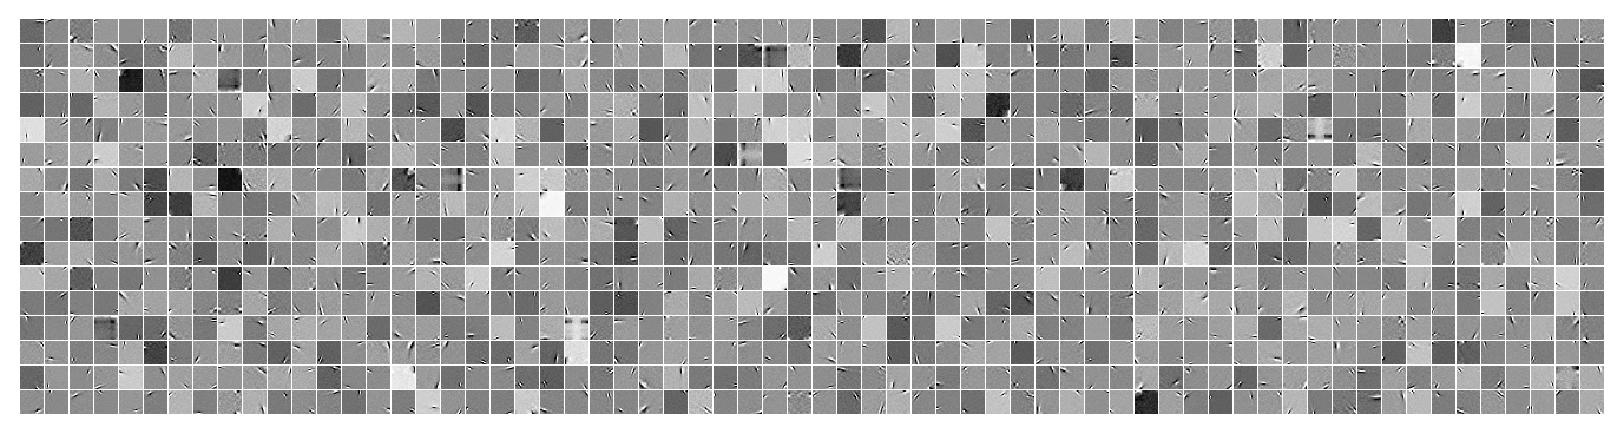

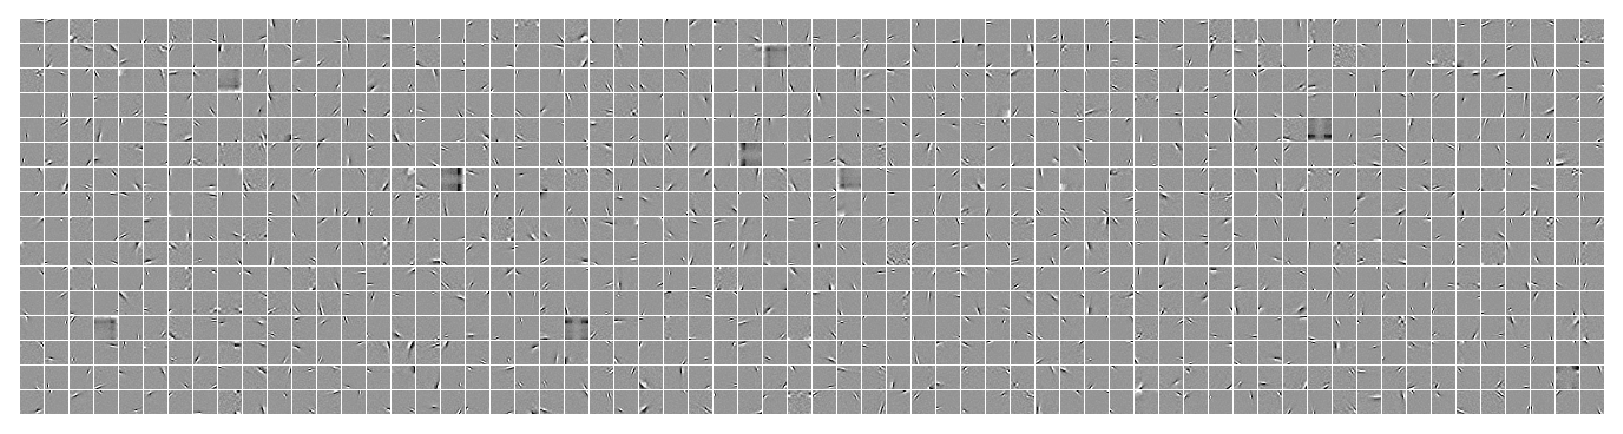

In [4]:
tr.model.show();
tr.model.show(method='abs-max');

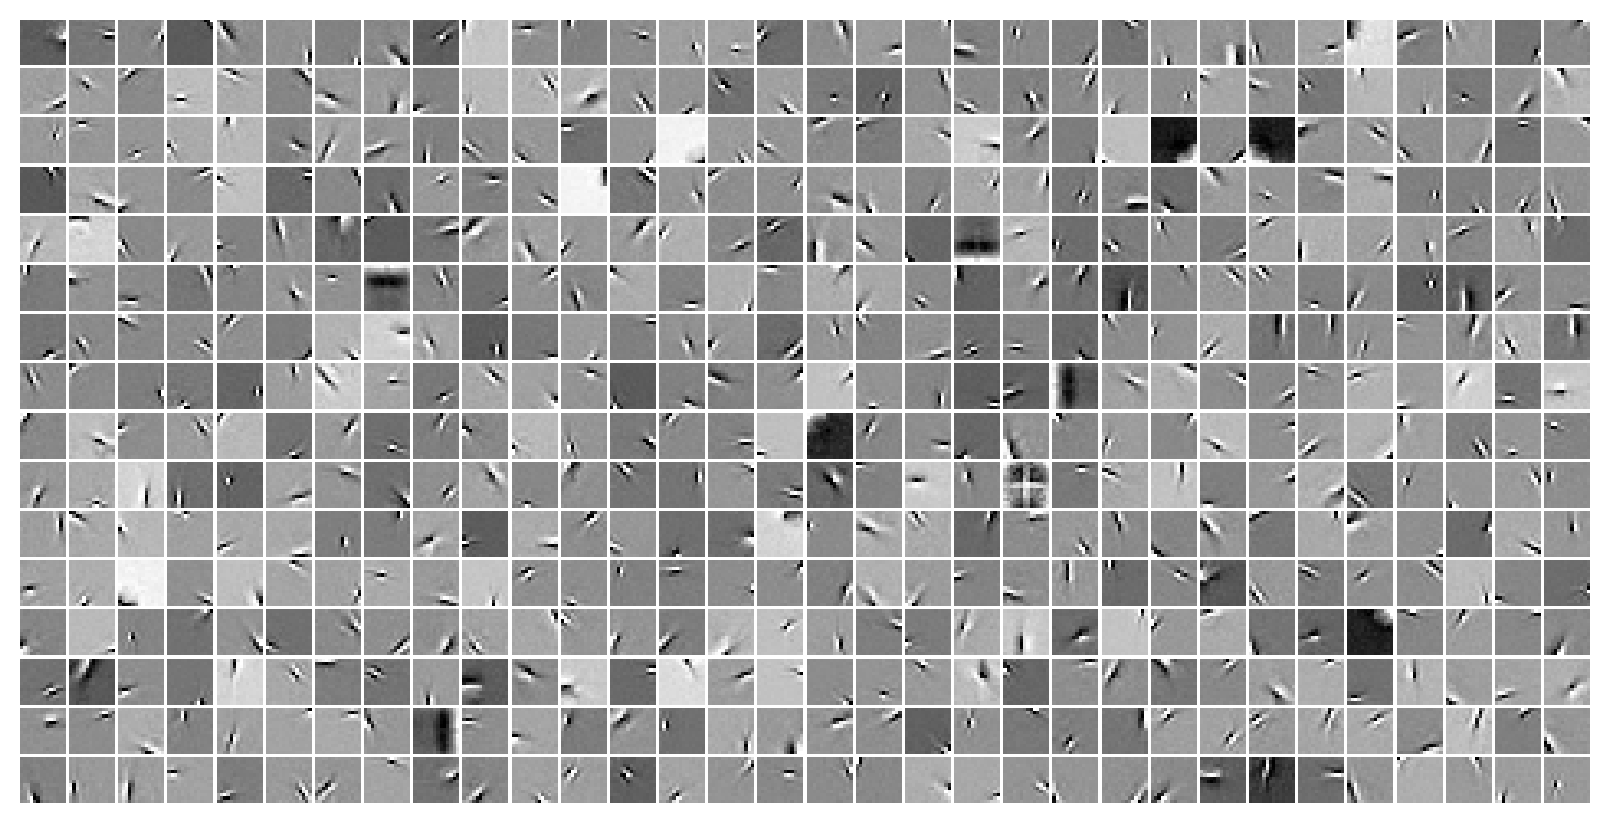

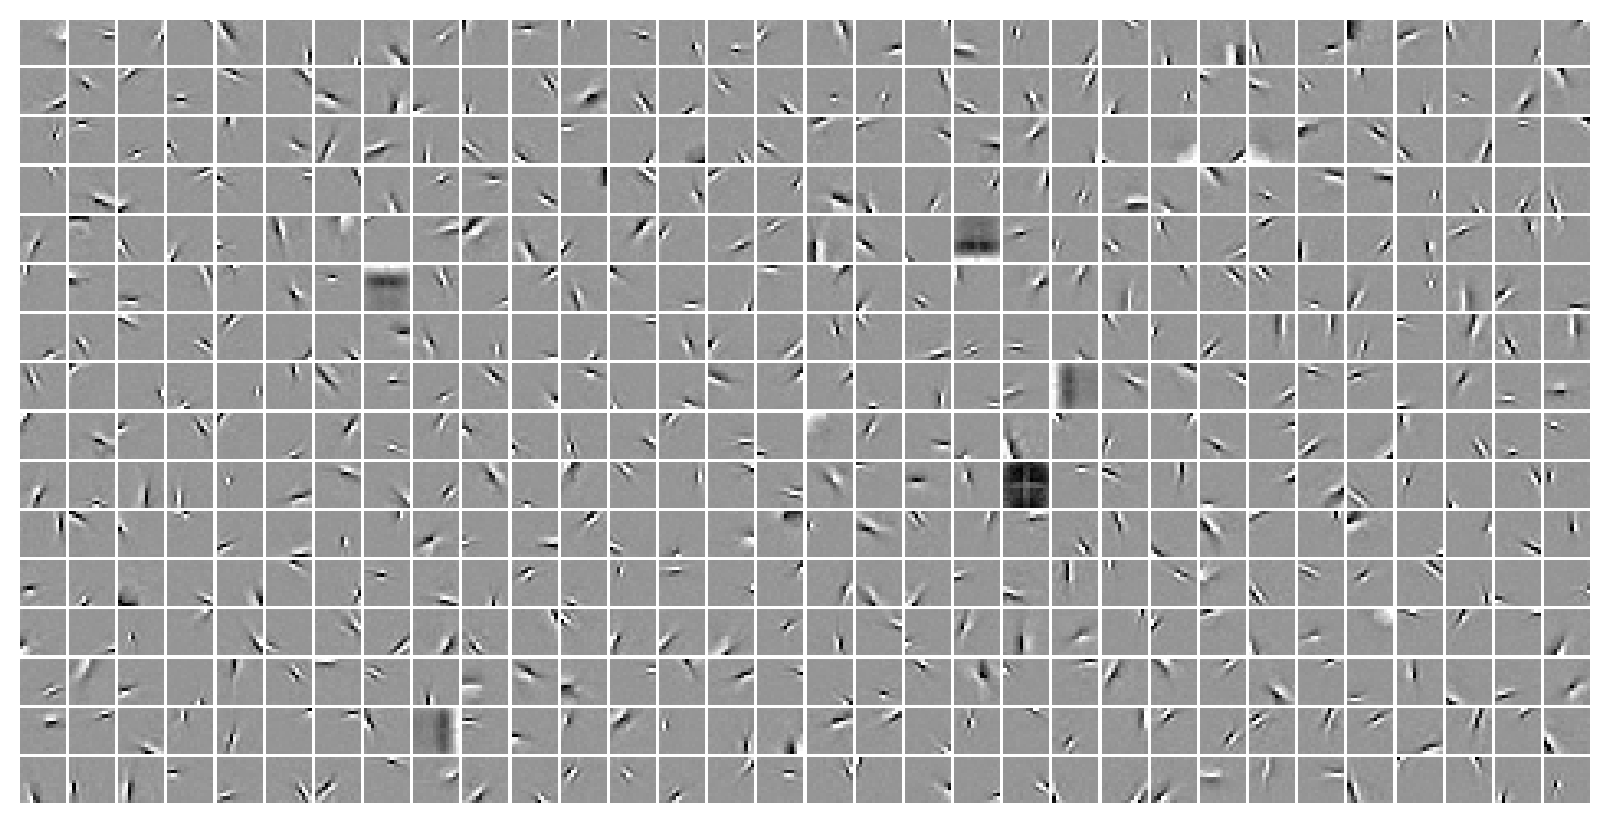

In [4]:
### Was: k = 512

100%|█████████████████████████████████| 10/10 [00:38<00:00,  3.88s/it]


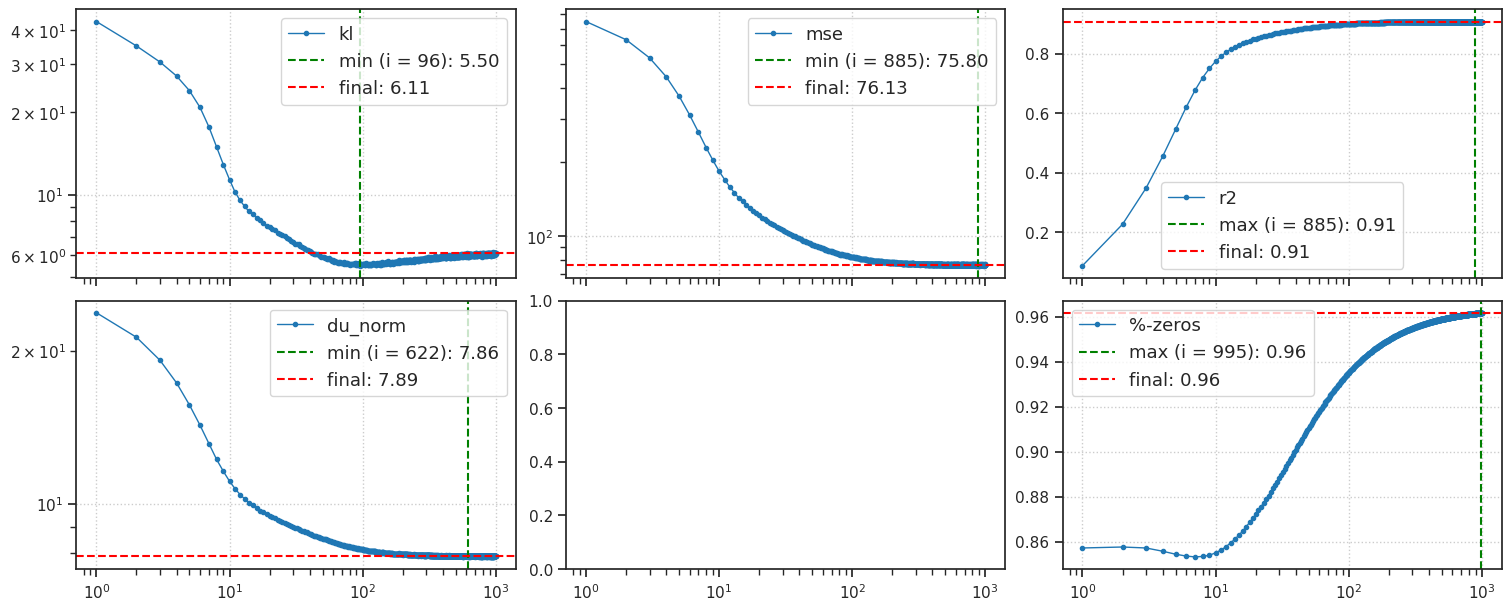

CPU times: user 57.4 s, sys: 18.1 s, total: 1min 15s
Wall time: 1min 15s


In [5]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=10,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='C0')

100%|█████████████████████████████████| 10/10 [04:00<00:00, 24.10s/it]


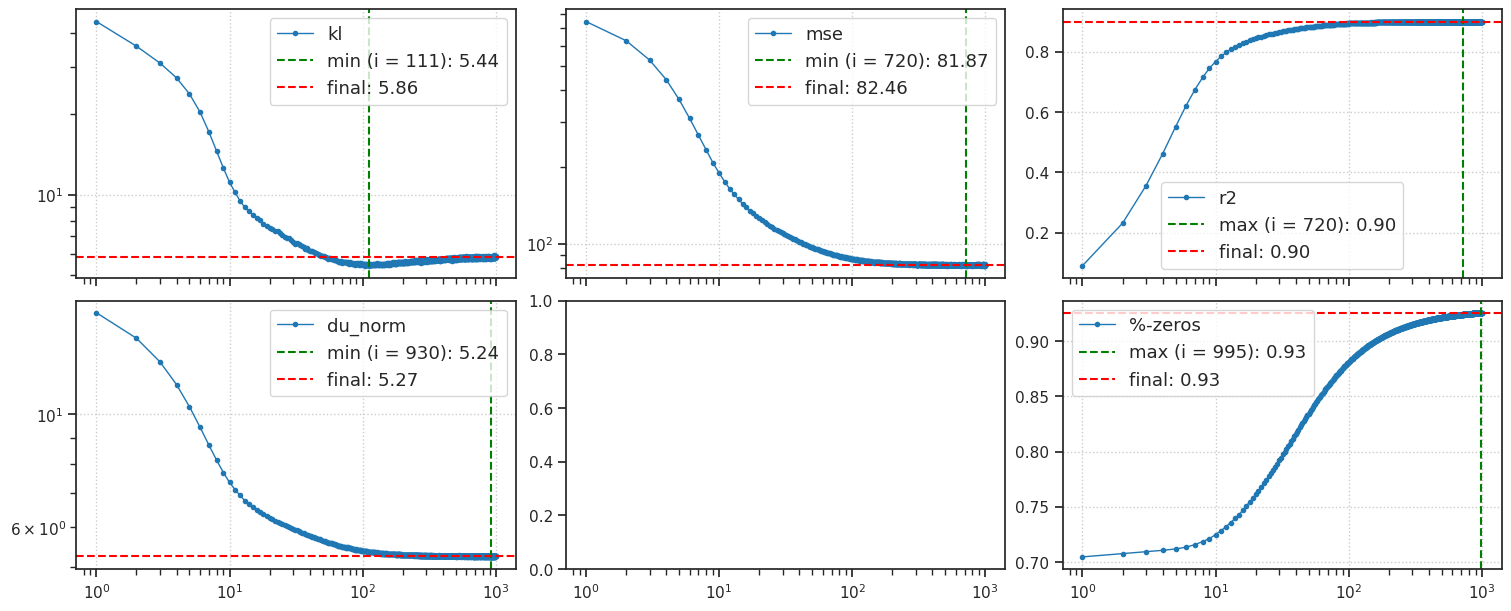

CPU times: user 4min 29s, sys: 9.19 s, total: 4min 38s
Wall time: 4min 38s


In [5]:
### Was: k = 512

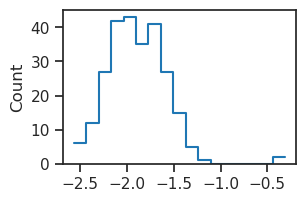

In [6]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
histplot(u0)
plt.show()

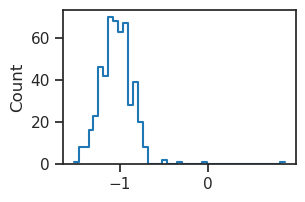

In [6]:
### Was: k = 512

In [7]:
# reduce u0 to very negative values

tr.model.layer.u_init[0].data.fill_(-6.0);

100%|█████████████████████████████████| 10/10 [00:35<00:00,  3.51s/it]


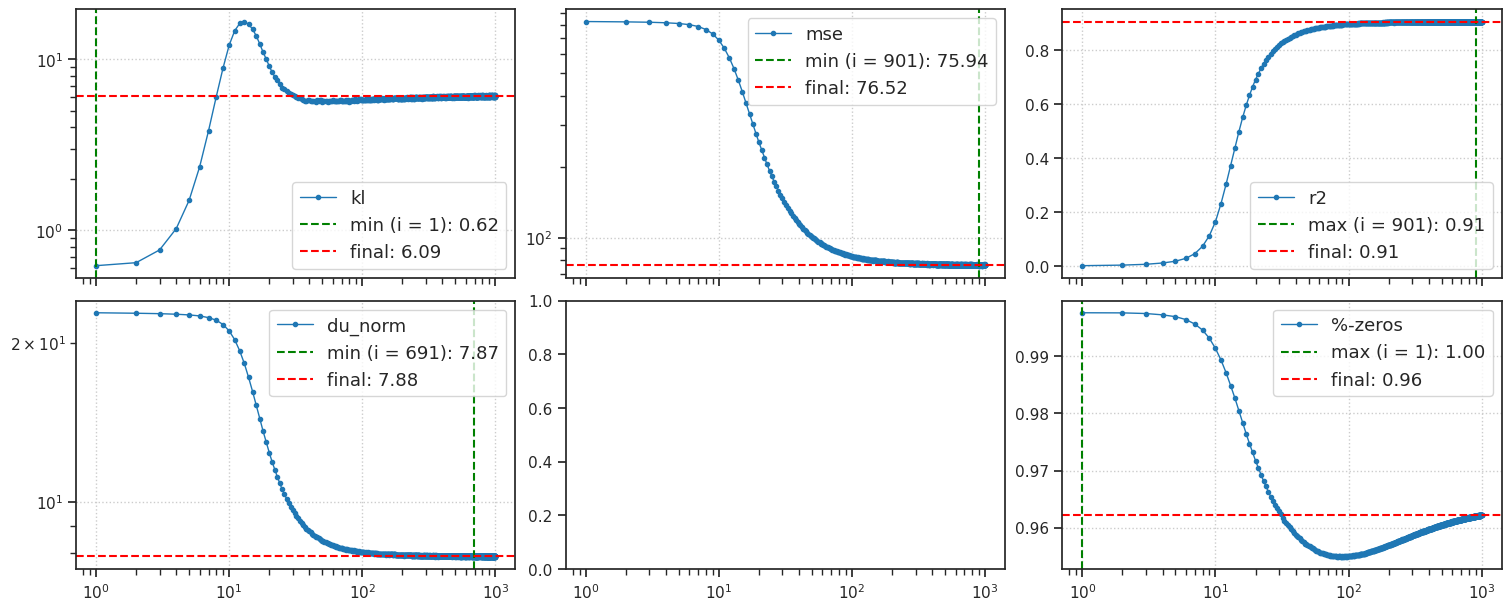

CPU times: user 56.4 s, sys: 15.2 s, total: 1min 11s
Wall time: 1min 11s


In [8]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=10,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='C0')

100%|█████████████████████████████████| 10/10 [03:59<00:00, 23.92s/it]


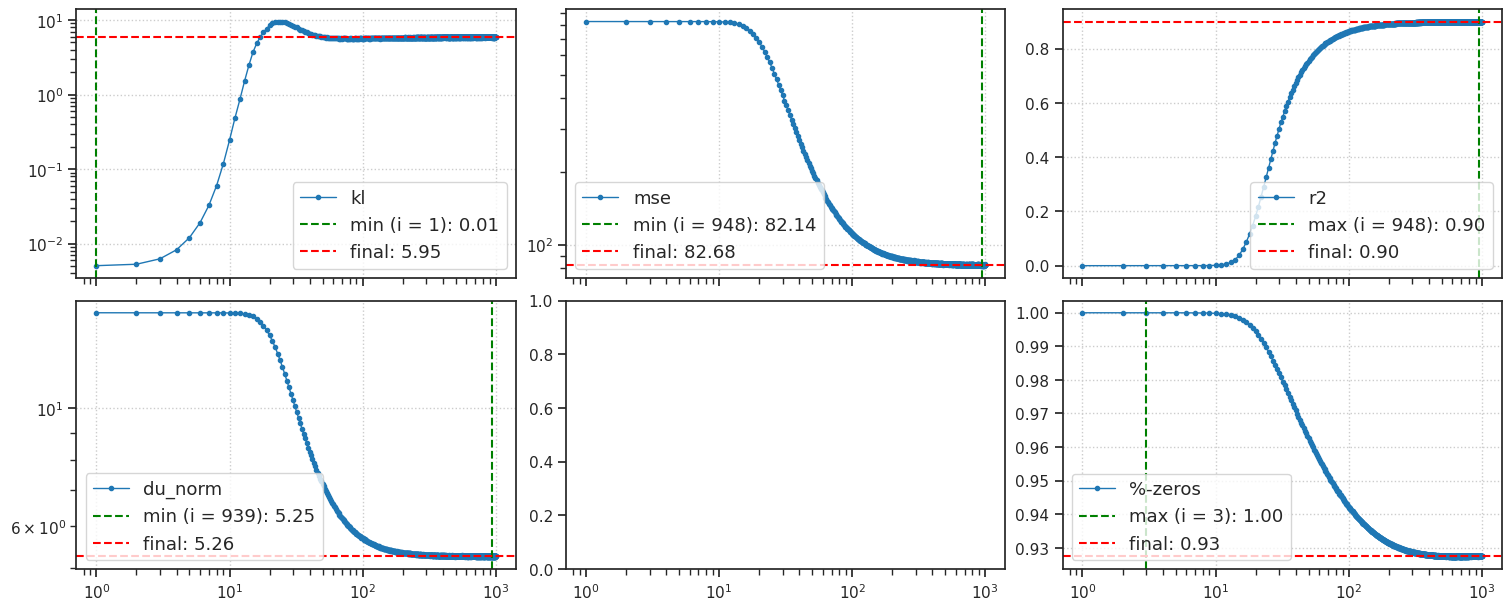

CPU times: user 4min 28s, sys: 7.94 s, total: 4min 36s
Wall time: 4min 36s


In [8]:
### Was: k = 512

## Load Kyoto image

In [5]:
# root directory
root = 'Datasets/Kyoto/processed'
root = add_home(root)

# load bw
bw = np.load(pjoin(root, 'kyoto_bnw.npy'))
bw.shape

(62, 500, 500)

In [6]:
from utils.imgproc import do_process, Whitening

In [7]:
wht, *_ = do_process(tr.to(bw).unsqueeze(1), device=device, crop_size=0)
wht_shift_rescale = (wht - wht.mean()) / wht.std()
wht_shift_rescale *= tr.dl_trn.dataset.tensors[0].std()
wht_shift_rescale = tr.to(wht_shift_rescale)
wht_shift_rescale.shape

torch.Size([62, 1, 500, 500])

In [8]:
# change num latent pixels to accomodate new stim dim

tr.model.update_model_dims(
    new_stim_dim=wht_shift_rescale.shape[-1],
    new_stride=1,
)


# reduce u0 to very negative values

tr.model.layer.u_init[0].data.fill_(-5.0);

#### TODO:

experiment with changing stride as well:

- Change to stride = 1
- Let's have more latents, why not?
    - This corresponds to larger n_latent_pixels
- How does recon change?
- How does the patchiness of the recon change?

In [9]:
wht_shift_rescale = wht_shift_rescale[[58, 59]]

## stimulus presentation

In [10]:
crop = 2

n_frames_gray = 20
n_frames_stim = 280
t_total = n_frames_gray + n_frames_stim

gray_screen = torch.zeros_like(wht_shift_rescale)

items = [
    'state', 'samples',
    'recon', 'r2', 'mse',
]

all_lamb = []
all_spks = []
all_recon = []

r2 = np_nans((len(wht_shift_rescale), t_total))
mse_perdim = np_nans((len(wht_shift_rescale), t_total))
portion_zeros = np_nans((len(wht_shift_rescale), t_total))

tr.model.eval()

for t in tqdm(range(n_frames_gray + n_frames_stim)):
    # set current time
    tr.model.update_time(t)
    
    # select current stimulus
    if t < n_frames_gray:
        current_frame = gray_screen
    else:
        current_frame = wht_shift_rescale
    
    # xtract ftrs
    output = tr.model.xtract_ftr(
        x=current_frame,
        return_extras=items,
    )

    # process: recon, mean firing rates & spike counts
    _lamb = tonp(torch.exp(output['state'][0]).mean(-3))
    _spks = tonp(output['samples'].mean(-3))
    all_lamb.append(_lamb[:, crop:-crop, crop:-crop])
    all_spks.append(_spks[:, crop:-crop, crop:-crop])
    all_recon.append(tonp(output['recon'].squeeze()))

    # save scores, r2, mse, sparsity
    r2[:, t] = tonp(output['r2'])
    mse_perdim[:, t] = (
        1000 * tonp(output['mse']) /
        np.prod(tr.model.cfg.input_sz)
    )
    portion_zeros[:, t] = tonp(torch.mean(
        (output['samples'] == 0).float(),
        dim=(1, 2, 3),
    ))

# stack into arrays
all_lamb = np.stack(all_lamb, axis=1)
all_spks = np.stack(all_spks, axis=1)
all_recon = np.stack(all_recon, axis=1)

all_lamb.shape, all_spks.shape, all_recon.shape

100%|█████████████████████████████████████████| 300/300 [01:18<00:00,  3.81it/s]


((2, 300, 477, 477), (2, 300, 477, 477), (2, 300, 500, 500))

In [11]:
img_idx = 0  # 58

r2[img_idx][-1]

0.8873547315597534

In [12]:
img = tonp(wht_shift_rescale[img_idx].squeeze())
vminmax = np.quantile(np.abs(img), q=0.97)
kws_img = dict(
    vmin=-vminmax,
    vmax=vminmax,
    cmap='Greys_r',
)

kws_lamb = dict(
    vmin=0.0,
    vmax=np.quantile(all_lamb, q=0.99),
    cmap='Spectral_r',
)
kws_spks = dict(
    vmin=0.0,
    vmax=np.quantile(all_spks, q=0.99),
    cmap='Spectral_r',
)


In [13]:
kws_img

{'vmin': -1.0396006727218627, 'vmax': 1.0396006727218627, 'cmap': 'Greys_r'}

In [14]:
kws_lamb

{'vmin': 0.0, 'vmax': 0.00602206215262413, 'cmap': 'Spectral_r'}

In [15]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Create figure
fig, axes = create_figure(2, 2, (8.9, 7.6))

# Initialize plots
ims = []
ims.append(axes[0, 0].imshow(all_lamb[img_idx, 0], **kws_lamb))
ims.append(axes[0, 1].imshow(all_spks[img_idx, 0], **kws_spks))
ims.append(axes[1, 0].imshow(all_recon[img_idx, 0], **kws_img))
ims.append(axes[1, 1].imshow(np.zeros_like(img), **kws_img))

# Add titles
current_r2 = max(0.0, r2[img_idx, 0]) * 100
current_percent_active = (1 - portion_zeros[img_idx, 0]) * 100
axes[0, 0].set_title(f'firing rates (avg across {tr.model.cfg.latent_channels} neurons)')
axes[0, 1].set_title(f'spike counts (avg) — active: {current_percent_active:0.1f} %')
axes[1, 0].set_title(f'reconstructed img — r2: {current_r2:0.1f} %')
axes[1, 1].set_title('input img')
title_2 = axes[0, 1].title
title_3 = axes[1, 0].title
title_4 = axes[1, 1].title

# Add colorbars
plt.colorbar(ims[0], ax=axes[0, 0], location='left')
plt.colorbar(ims[1], ax=axes[0, 1])
plt.colorbar(ims[2], ax=axes[1, 0], location='left')
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1])
remove_ticks(axes, False)

# Animation function
def animate(time_idx):
    ims[0].set_data(all_lamb[img_idx, time_idx])
    ims[1].set_data(all_spks[img_idx, time_idx])
    ims[2].set_data(all_recon[img_idx, time_idx])

    # Update dynamic titles
    current_r2 = max(0.0, r2[img_idx, time_idx]) * 100
    current_percent_active = (1 - portion_zeros[img_idx, time_idx]) * 100
    title_2.set_text(f'spike counts (avg) — active: {current_percent_active:0.1f} %')
    title_3.set_text(f'reconstructed img — r2: {current_r2:0.1f} %')

    # Update input image and title color
    if time_idx < n_frames_gray:
        ims[3].set_data(np.zeros_like(img))
        title_4.set_color('black')
    else:
        ims[3].set_data(img)
        title_4.set_color('red')

    return ims + [title_2, title_3, title_4]

# Create animation
anim = animation.FuncAnimation(
    fig=fig,
    func=animate,
    frames=t_total,
    interval=100,
    blit=True,
)

# Save as MP4
fname = '_'.join([
    f"z-{str(tr.model.cfg.latent_sz).replace(' ', '')}",
    f"s-{tr.model.cfg.latent_stride}",
    f"kyoto-{img_idx}",
])
anim.save(f'{fname}.mp4', writer='ffmpeg', fps=10, dpi=150)
plt.close()

[(0.0, 1.0)]

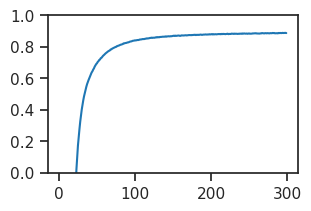

In [16]:
fig, ax = create_figure()
ax.plot(r2[img_idx])
ax.set(ylim=(0, 1))

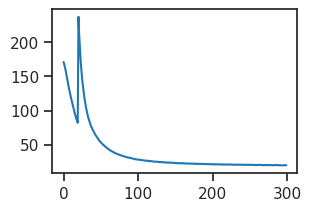

In [17]:
fig, ax = create_figure()
ax.plot(mse_perdim[img_idx])
#ax.set(ylim=(0, 1))

In [18]:
r2[img_idx][-1]

0.8873547315597534

## Sparsity analysis

In [6]:
output = tr.xtract_ftr(data_batch_sz=2000)
list(output)

100%|███████████████████████████████████| 2/2 [00:07<00:00,  3.93s/it]


['r2', 'mse', 'du_norm_0', 'samples', 'state_0', 'times']

In [7]:
z = output['samples'][:, -1]
z.shape

(2713, 512, 4, 4)

In [8]:
life, pop, portions = sparse_score(flatten_np(z, start_dim=1, end_dim=-1), cutoff=0.01)

In [9]:
life.mean(), pop.mean(), portions

(0.9572569,
 0.95816654,
 {'0': 92.6, '1': 2.2, '2': 1.5, '3': 1.0, '4': 0.7, '5+': 1.9})

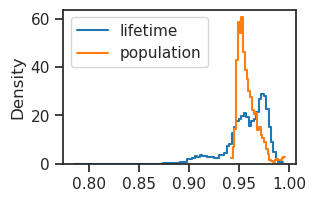

In [10]:
histplot(life, label='lifetime', stat='density')
histplot(pop, label='population', stat='density')
plt.legend()
plt.show()

## Load Kyoto image

In [11]:
root = 'Datasets/Kyoto/processed'
root = add_home(root)

os.listdir(root)

['kyoto_bnw.npy', 'kyoto_color.npy']

In [12]:
bw = np.load(pjoin(root, 'kyoto_bnw.npy'))
bw.shape

(62, 500, 500)

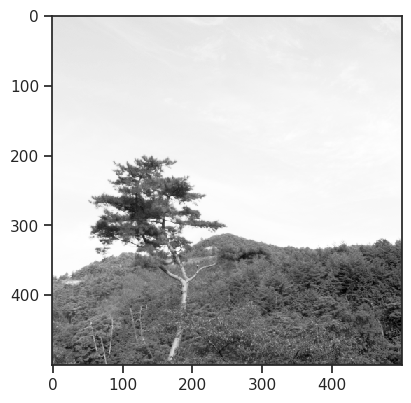

In [13]:
img_i = 58

fig, ax = create_figure(1, 1, (4, 4))
ax.imshow(bw[img_i], cmap='Greys_r')
plt.show()

In [14]:
print({k: v for k, v in vars(tr.model.cfg).items() if 'latent' in k or 'input' in k})

{'latent_channels': 512, 'latent_pixels': 4, 'latent_stride': 6, 'input_sz': (1, 32, 32), 'latent_sz': (512, 4, 4)}

In [15]:
print(tr.model.layer.dec)

ConvDictionary(in_channels=512, out_channels=1, kernel_size=14, stride=6)

In [22]:
from base.helper import conv_arithmetic

df = conv_arithmetic(
    input_size=None,
    output_size=500,
    kernel_size=14,
    stride=6,
    padding=0,
    deconv=True,
)
df

,mode,computed,parameter,value
0,deconv,True,input_size,82
1,deconv,False,output_size,500
2,deconv,False,kernel_size,14
3,deconv,False,stride,6
4,deconv,False,padding,0


In [23]:
df.loc[df['computed']]

,mode,computed,parameter,value
0,deconv,True,input_size,82


In [24]:
latent_pixels = df.loc[df['parameter'] == 'input_size', 'value'].item()
latent_pixels

82

In [25]:
tr.model.cfg.latent_pixels = latent_pixels
tr.model.cfg.latent_sz = (tr.model.cfg.latent_channels, latent_pixels, latent_pixels)
tr.model.cfg.input_sz = (1, 500, 500)
tr.model.layer.dec_log_sigma = nn.Parameter(
    torch.zeros((1, 1, 500, 500), device=tr.device).float(),
    requires_grad=False,
)

In [26]:
print({k: v for k, v in vars(tr.model.cfg).items() if 'latent' in k})

{'latent_channels': 512, 'latent_pixels': 82, 'latent_stride': 6, 'latent_sz': (512, 82, 82)}

In [27]:
results = tr.xtract_ftr(
    data=tr.to(bw).unsqueeze(1),
    t_total=2000,
    save_freq=200,
    return_recon=True,
)
list(results)

100%|██████████████████████████████████| 1/1 [02:13<00:00, 133.66s/it]


['r2', 'mse', 'du_norm_0', 'samples', 'state_0', 'recon', 'times']

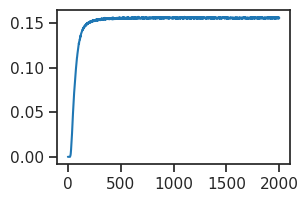

In [28]:
plot(results['r2'])
plt.show()

In [29]:
z = results['samples'][:, -1]
z.shape

(62, 512, 82, 82)

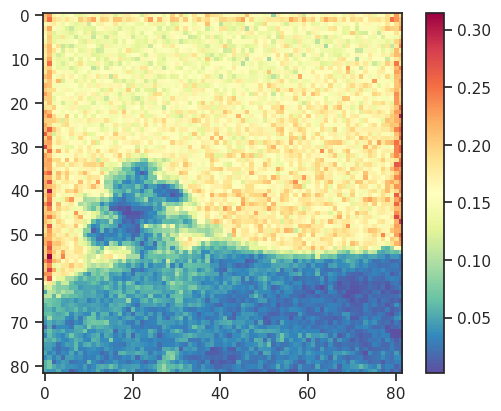

In [30]:
fig, ax = create_figure(1, 1, (5, 4))
im = ax.imshow(tonp(z[img_i].mean(0)), cmap='Spectral_r')
plt.colorbar(im, ax=ax)
plt.show()

In [31]:
results['recon'].shape

(62, 11, 1, 500, 500)

In [32]:
img_i

58

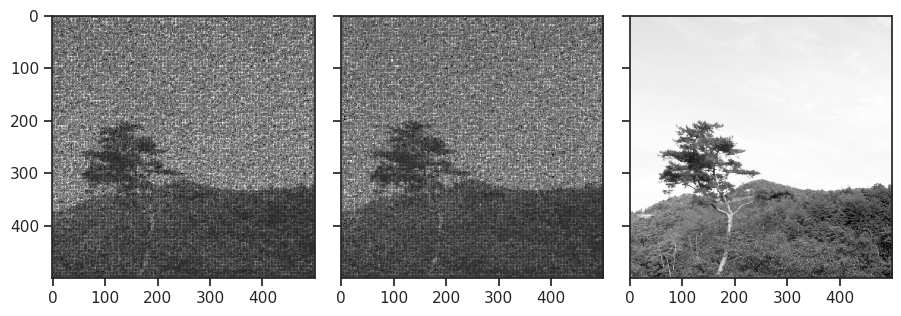

In [33]:
fig, axes = create_figure(1, 3, (9, 3), 'all', 'all')

x2p = tonp(results['recon'][img_i, 1].squeeze())
axes[0].imshow(x2p, cmap='Greys_r')

x2p = tonp(results['recon'][img_i, -1].squeeze())
axes[1].imshow(x2p, cmap='Greys_r')

axes[-1].imshow(bw[img_i], cmap='Greys_r')
plt.show()

In [38]:
from utils.imgproc import do_process, Whitening

In [39]:
x_wt, x_wt_cn, x_wt_cn_zs = do_process(tr.to(bw).unsqueeze(1), crop_size=0)
x_wt_cn_zs.shape

torch.Size([62, 1, 500, 500])

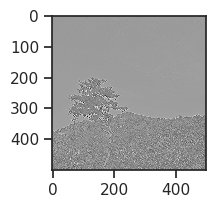

In [40]:
imshow(tonp(x_wt[img_i, 0]), cmap='Greys_r')
plt.show()

In [41]:
whitener = Whitening((500, 500), f_0=0.5, n=4, batched=True)

In [42]:
wht = whitener(tr.to(bw).unsqueeze(1))
wht.shape

torch.Size([62, 1, 500, 500])

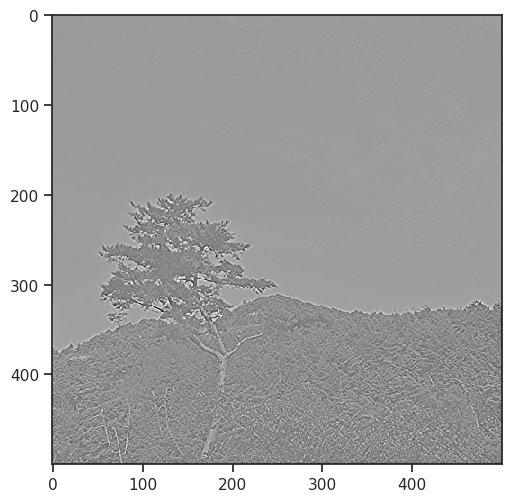

In [43]:
fig, ax = create_figure(1, 1, ( 5, 5))
ax.imshow(tonp(wht[img_i, 0]), cmap='Greys_r')
plt.show()

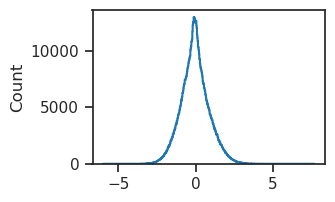

In [53]:
histplot(tr.dl_trn.dataset.tensors[0][:1000].ravel())
plt.show()

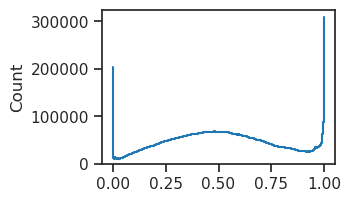

In [54]:
histplot(bw.ravel())
plt.show()

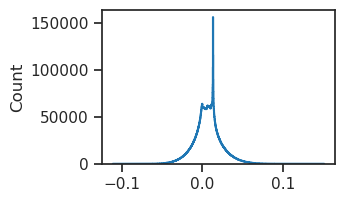

In [55]:
histplot(wht.ravel())
plt.show()

In [59]:
wht_shift_rescale = (wht - wht.mean()) / wht.std()
wht_shift_rescale *= tr.dl_trn.dataset.tensors[0].std()
wht_shift_rescale.shape

torch.Size([62, 1, 500, 500])

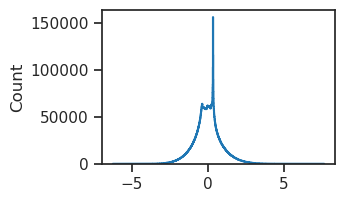

In [60]:
histplot(wht_shift_rescale.ravel())
plt.show()

In [ ]:
results = tr.xtract_ftr(
    data=tr.to(wht_shift_rescale),
    t_total=200,
    save_freq=1,
    return_recon=True,
)
list(results)

  0%|                                           | 0/1 [00:00<?, ?it/s]

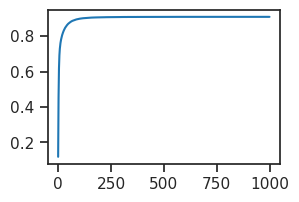

In [62]:
plot(results['r2'])
plt.show()

In [63]:
results['recon'].shape

(62, 11, 1, 500, 500)

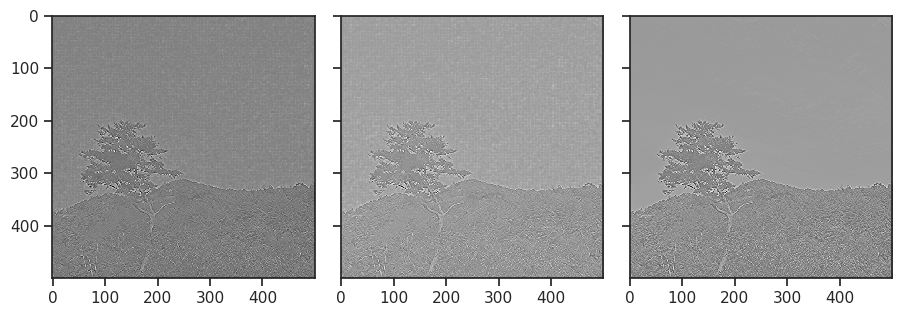

In [64]:
fig, axes = create_figure(1, 3, (9, 3), 'all', 'all')

x2p = tonp(results['recon'][img_i, 1].squeeze())
axes[0].imshow(x2p, cmap='Greys_r')

x2p = tonp(results['recon'][img_i, -1].squeeze())
axes[1].imshow(x2p, cmap='Greys_r')

axes[-1].imshow(tonp(wht[img_i, 0]), cmap='Greys_r')
plt.show()

In [1]:
plot(results['r2'])

NameError: name 'plot' is not defined

In [68]:
results['r2'][-1]

0.90920043

In [69]:
results['r2'][200]

0.9066059

## Analyze

### sort data

In [4]:
x_vld = tr.dl_vld.dataset.tensors[0]
var = torch.var(x_vld, dim=(1, 2, 3))
contrast_sort = torch.argsort(var)
x_vld = x_vld[contrast_sort]
tr.dl_vld.dataset.tensors = (x_vld, )

### plot

#### High contrast:

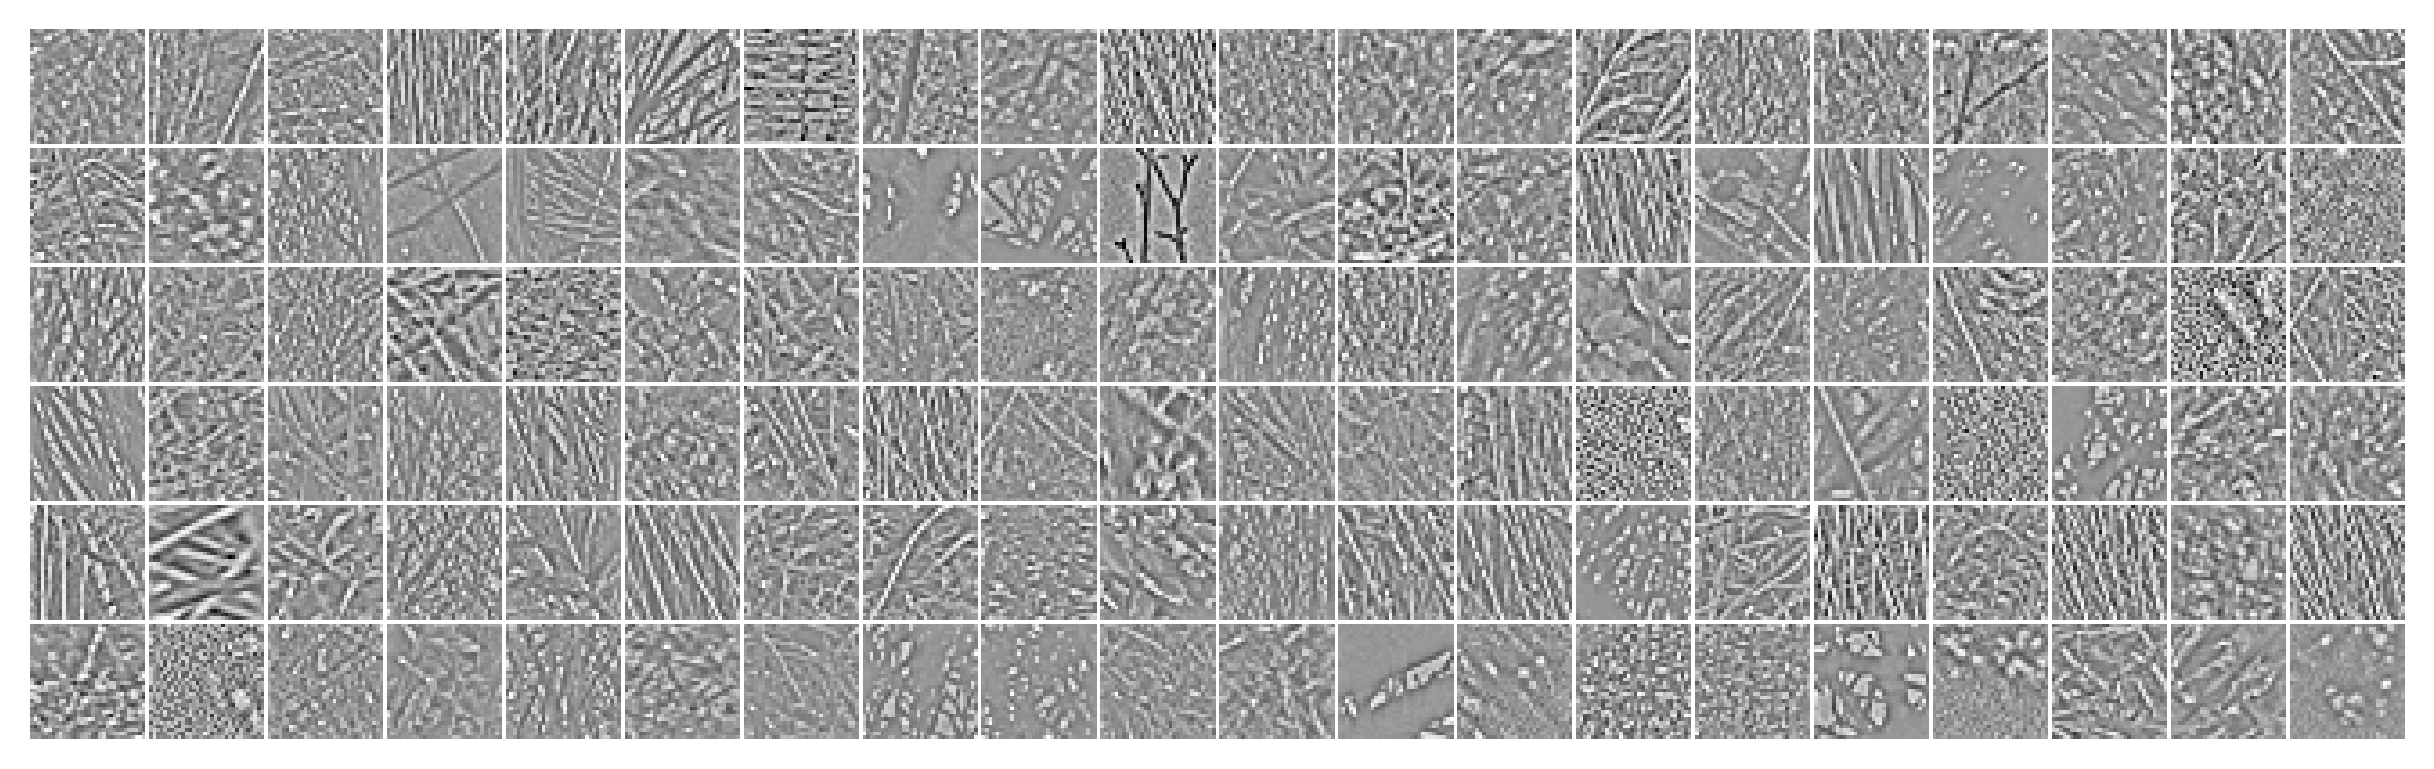

In [5]:
x2p = tonp(tr.dl_vld.dataset.tensors[0])[-120:]
plot_weights(x2p, nrows=6, dpi=300, method='abs-max');

#### Low contrast:

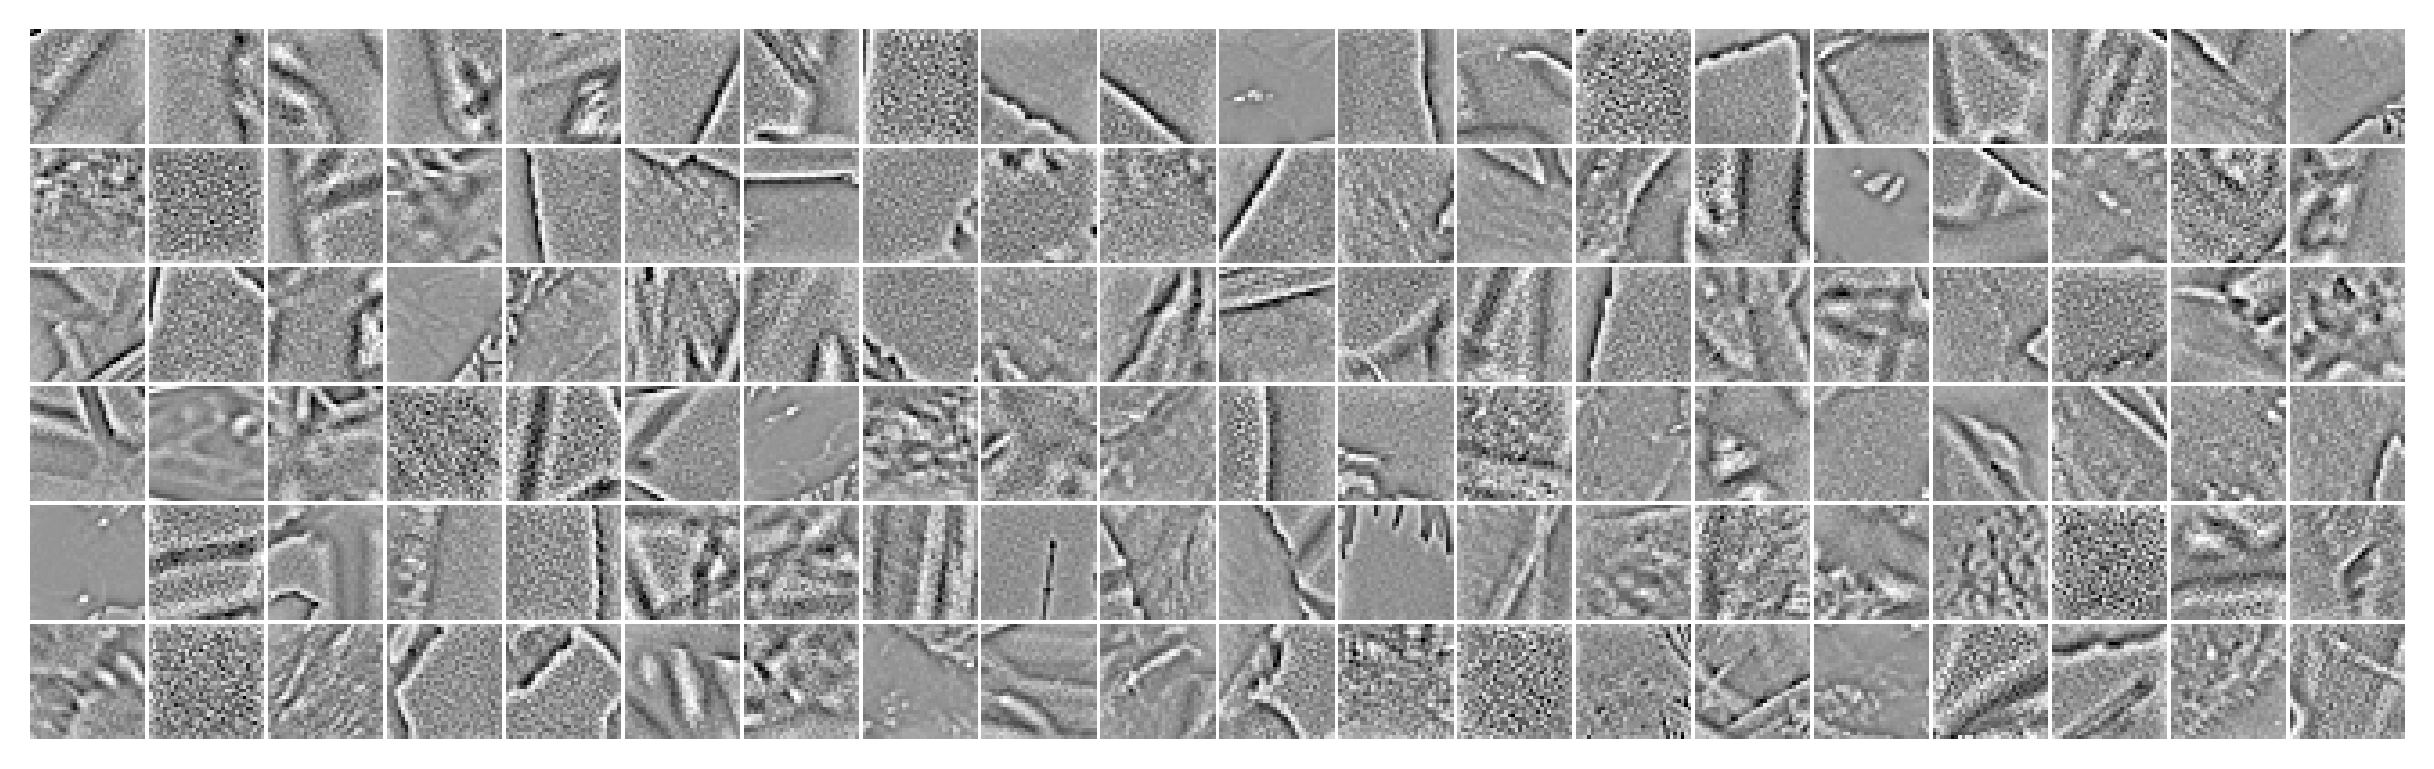

In [6]:
x2p = tonp(tr.dl_vld.dataset.tensors[0])[:120]
plot_weights(x2p, nrows=6, dpi=300, method='abs-max');

### Xtract ftrs

In [11]:
results = tr.analysis(t_total=111, n_data_batches=-1, avg_samples=False)
list(results)

100%|███████████████████████████████| 114/114 [00:48<00:00,  2.35it/s]


['kl',
 'r2',
 'mse',
 'loss',
 'du_norm',
 'lifetime',
 'population',
 '%-zeros',
 'state_final',
 'samples_final']

In [17]:
var.shape, results['r2'][:, -1].shape

(torch.Size([11303]), (11303,))

In [28]:
sp_stats.spearmanr(tonp(var), results['r2'][:, -1])

SignificanceResult(statistic=-0.010619488995188308, pvalue=0.25892990834104573)

In [22]:
r2_last = results['r2'][:, -1]
r2_last.shape

(11303,)

In [23]:
r2_last[:200].mean(), r2_last[-200:].mean()

(0.8733722, 0.90817565)

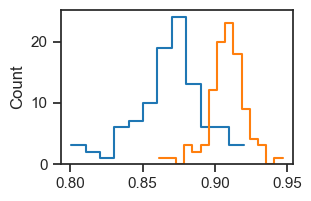

In [27]:
histplot(r2_last[:100], color='C0')
histplot(r2_last[-100:], color='C1')
plt.show()

In [30]:
tr.model.layer.samples.shape

torch.Size([3, 256, 8, 8])

In [37]:
z = tonp(tr.model.layer.samples[2])
z.shape

(256, 8, 8)

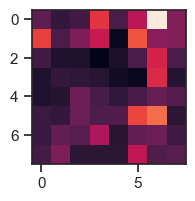

In [38]:
plt.imshow(z.mean(0))
plt.show()

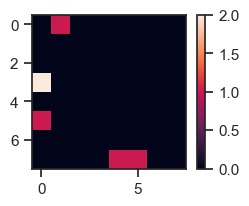

In [47]:
plt.imshow(z[14])
plt.colorbar()
plt.show()

In [50]:
portions = sparse_score(z.ravel(), cutoff=0.01)[-1]

/home/hadi/Dropbox/git/_TemporalSC/analysis/sparse.py:15: RuntimeWarning: divide by zero encountered in divide
  score /= (1 - 1 / m)
/home/hadi/Dropbox/git/_TemporalSC/analysis/sparse.py:15: RuntimeWarning: invalid value encountered in divide
  score /= (1 - 1 / m)


In [51]:
portions

{'0': 93.5, '1': 3.9, '2': 1.1, '3': 0.6, '4+': 0.9}

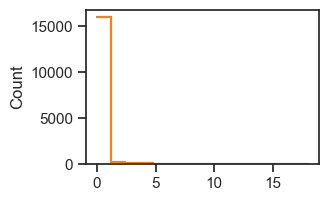

In [49]:
histplot(z.ravel())
plt.show()